# 🎯 Instagram Content Strategy — Travel Mex Tours
## Notebook 04: Content Strategy Analysis

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Go beyond basic metrics to uncover **what content actually works** for Travel Mex Tours.

### Key Methodological Notes
- **Primary metric:** Performance Score (corrects reach bias)
- **Minimum posts per group:** 10 for reliable comparisons
- **Marginal significance:** p < 0.10 reported as trend, not conclusion
- Hour × Content Type analysis excluded — insufficient data

### Analyses
| # | Analysis | Business Question |
|---|----------|-------------------|
| 1 | Post Clustering | What patterns define High Impact posts? |
| 2 | Save Rate vs Share Rate | Does our audience save for later or share with friends? |
| 3 | Destination Analysis | Which regions drive the most impact? (≥10 posts only) |
| 4 | Caption Analysis | Do specific tours and caption length affect performance? |
| 5 | Recommended Experiments | What data should we collect next? |


## 1. Setup & Data Load

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy import stats

BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45", "#4ade80", "#f87171"]

FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

MIN_DEST_POSTS = 10  # minimum posts for reliable destination analysis
ALPHA          = 0.05

print("✅ Setup complete")


✅ Setup complete


In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

DATA_DIR  = Path("../../data/instagram/")
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)
if not csv_files:
    raise FileNotFoundError("No CSV found in data/instagram/")

df_raw   = load_instagram_csv(csv_files[0])
df, meta = preprocess_df(df_raw)

er_col        = meta["engagement_rate_col"]
ps_col        = meta["performance_score_col"]
tier_col      = meta["performance_tier_col"]
tier_rel      = meta["performance_tier_relative_col"]
type_col      = meta.get("type_col")
time_slot_col = meta.get("time_slot_col")
likes_col     = meta.get("likes_col")
saves_col     = meta.get("saves_col")
shares_col    = meta.get("shares_col")
comments_col  = meta.get("comments_col")
reach_col     = meta.get("reach_col")
desc_col      = next((c for c in df.columns if "description" in c.lower()), None)

print(f"✅ Data loaded → {len(df)} posts")
print(f"   Primary metric   : {ps_col}")
print(f"   Secondary metric : {er_col}")
print(f"   Description col  : {desc_col}")


✅ Loaded: InstagramData.csv  |  125 rows × 18 cols  |  UNKNOWN
✅ Preprocessing completed!
   → Date column            : publish_time
   → ER calculated via      : REACH
   → Avg ER                 : 15.36%
   → Avg Performance Score  : 30.25/100
   → vs Maximum Potential   : High=0 | Medium=46 | Low=79
   → vs Other Posts         : Above Avg=31 | Avg=60 | Below Avg=34
   → Time slots:
      🌅 Early Morning (6-9): 89 posts | avg ER 15.77%
      ☀️ Late Morning (10-12): 16 posts | avg ER 14.29%
      🌤️ Afternoon (13-17): 16 posts | avg ER 13.38%
✅ Data loaded → 125 posts
   Primary metric   : performance_score
   Secondary metric : engagement_rate_pct
   Description col  : description


## 2. Post Clustering — What Patterns Define High Impact Posts?

K-Means clustering groups posts by performance patterns.
Primary clustering metric: **Performance Score** (corrects reach bias).

> Note: Low Impact cluster may show higher ER than Solid Posts — this is expected
> and confirms reach bias. Posts with lower reach naturally have higher ER
> even with similar absolute engagements.


In [3]:
cluster_features = [c for c in [
    ps_col, er_col, reach_col, likes_col,
    saves_col, shares_col, comments_col,
    "save_rate_pct", "share_rate_pct", "total_engagements"
] if c and c in df.columns]

cluster_df = df[cluster_features].dropna().copy()
print(f"Features used  : {cluster_features}")
print(f"Posts available: {len(cluster_df)}")


Features used  : ['performance_score', 'engagement_rate_pct', 'reach', 'likes', 'saves', 'shares', 'comments', 'save_rate_pct', 'share_rate_pct', 'total_engagements']
Posts available: 123


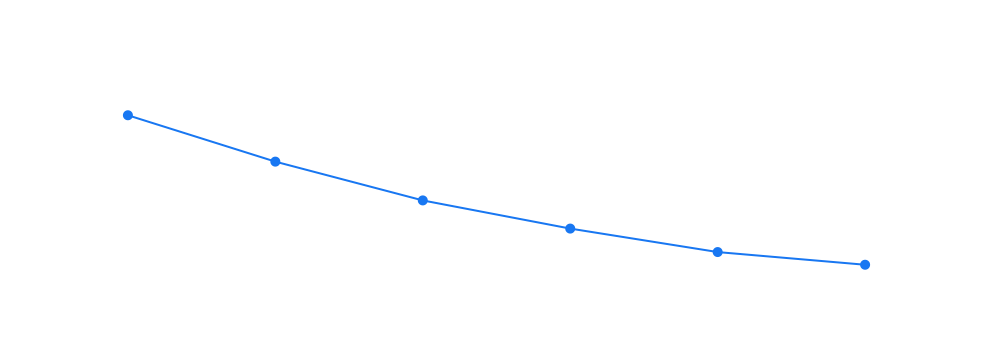

Look for the elbow — where inertia stops dropping sharply.


In [4]:
# Elbow method
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)

inertias = []
K_range  = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig = px.line(
    x=list(K_range), y=inertias, markers=True,
    labels={"x": "Number of Clusters (K)", "y": "Inertia"},
    title="Elbow Method — Finding Optimal Number of Clusters",
    color_discrete_sequence=[BRAND_BLUE]
)
fig.update_traces(marker=dict(size=10))
fig.update_layout(
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.show()
print("Look for the elbow — where inertia stops dropping sharply.")


In [5]:
OPTIMAL_K = 3   # ← adjust based on elbow chart

km = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_df["cluster"] = km.fit_predict(X_scaled)

df.loc[cluster_df.index, "cluster"] = cluster_df["cluster"]
df["cluster"] = df["cluster"].fillna(-1).astype(int)

# Name clusters by Performance Score
cluster_ps      = cluster_df.groupby("cluster")[ps_col].mean()
sorted_clusters = cluster_ps.sort_values(ascending=False)
labels          = ["🔥 High Impact", "✅ Solid Posts", "📉 Low Impact"]
cluster_names   = {cid: labels[i] if i < len(labels) else f"Cluster {cid}"
                   for i, (cid, _) in enumerate(sorted_clusters.items())}
high_cluster    = sorted_clusters.index[0]
low_cluster     = sorted_clusters.index[-1]

print("CLUSTER RESULTS:")
print()
for cid, name in cluster_names.items():
    sub    = cluster_df[cluster_df["cluster"] == cid]
    avg_ps = sub[ps_col].mean()
    avg_er = sub[er_col].mean()
    n      = len(sub)
    print(f"   {name:22s}: {n:3d} posts | Score={avg_ps:.2f} | ER={avg_er:.2f}%")

print()
print("⚠️  Note: Low Impact may show higher ER than Solid Posts.")
print("   This is expected — confirms reach bias.")
print("   Performance Score is the correct ranking metric.")


CLUSTER RESULTS:

   🔥 High Impact         :  15 posts | Score=42.53 | ER=21.74%
   ✅ Solid Posts         :  21 posts | Score=40.93 | ER=13.24%
   📉 Low Impact          :  87 posts | Score=26.25 | ER=14.77%

⚠️  Note: Low Impact may show higher ER than Solid Posts.
   This is expected — confirms reach bias.
   Performance Score is the correct ranking metric.


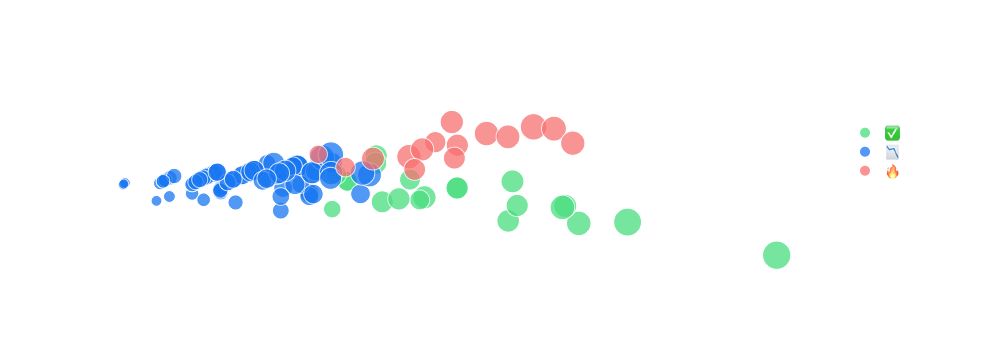

PCA explains 61.7% of total variance


In [6]:
# PCA visualization
pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1":     X_2d[:, 0],
    "PC2":     X_2d[:, 1],
    "Cluster": cluster_df["cluster"].map(cluster_names),
    ps_col:    cluster_df[ps_col].round(2),
    er_col:    cluster_df[er_col].round(2),
})

fig = px.scatter(
    pca_df, x="PC1", y="PC2",
    color="Cluster", size=ps_col,
    hover_data={ps_col: True, er_col: True, "PC1": False, "PC2": False},
    color_discrete_sequence=["#4ade80", BRAND_BLUE, "#f87171"],
    title="Post Clusters — 2D Visualization (PCA)",
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)",
    }
)
fig.update_traces(marker=dict(opacity=0.75, line=dict(width=1, color="white")))
fig.update_layout(
    plot_bgcolor="rgba(0,0,0,0)",
    paper_bgcolor="rgba(0,0,0,0)",
    font_color="rgba(255,255,255,0.8)"
)
fig.show()
print(f"PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")


In [7]:
# High Impact vs Low Impact differences
high = cluster_df[cluster_df["cluster"] == high_cluster]
low  = cluster_df[cluster_df["cluster"] == low_cluster]

profile_cols = [c for c in [ps_col, er_col, reach_col, likes_col,
                              saves_col, shares_col, "total_engagements"]
                if c and c in cluster_df.columns]

print("=" * 60)
print("  HIGH IMPACT vs LOW IMPACT — KEY DIFFERENCES")
print("=" * 60)
for col in profile_cols:
    h_mean = high[col].mean()
    l_mean = low[col].mean()
    diff   = ((h_mean - l_mean) / l_mean * 100) if l_mean != 0 else 0
    print(f"  {col:30s}: {h_mean:.2f} vs {l_mean:.2f}  ({diff:+.0f}%)")
print("=" * 60)
print("\n→ Study your High Impact posts and replicate these patterns!")


  HIGH IMPACT vs LOW IMPACT — KEY DIFFERENCES
  performance_score             : 42.53 vs 26.25  (+62%)
  engagement_rate_pct           : 21.74 vs 14.77  (+47%)
  reach                         : 39.07 vs 35.60  (+10%)
  likes                         : 5.27 vs 3.92  (+34%)
  saves                         : 0.33 vs 0.00  (+0%)
  shares                        : 2.40 vs 0.08  (+2883%)
  total_engagements             : 8.07 vs 4.08  (+98%)

→ Study your High Impact posts and replicate these patterns!


## 3. Save Rate vs Share Rate

**Save rate** = audience saves for future travel planning  
**Share rate** = audience recommends Travel Mex to friends

Both calculated relative to reach — corrects for reach bias.


In [8]:
if "save_rate_pct" in df.columns and "share_rate_pct" in df.columns:
    sr_df    = df[["save_rate_pct", "share_rate_pct", er_col, ps_col, tier_rel]].dropna()
    avg_save  = sr_df["save_rate_pct"].mean()
    avg_share = sr_df["share_rate_pct"].mean()

    print(f"Average Save Rate  : {avg_save:.2f}%")
    print(f"Average Share Rate : {avg_share:.2f}%")
    print()

    if avg_save > avg_share:
        print("✈️  INSIGHT: Audience SAVES more than they SHARE.")
        print("   → They are travel planners — bookmarking posts for future trips.")
        print("   → CTA: 'Save this for your next trip ✈️'")
    else:
        print("📢 INSIGHT: Audience SHARES more than they SAVE.")
        print("   → They recommend Travel Mex to friends.")
        print("   → CTA: 'Comparte con alguien que necesita unas vacaciones 🌴'")
else:
    print("⚠️  Save/share rate columns not found.")


Average Save Rate  : 0.41%
Average Share Rate : 1.00%

📢 INSIGHT: Audience SHARES more than they SAVE.
   → They recommend Travel Mex to friends.
   → CTA: 'Comparte con alguien que necesita unas vacaciones 🌴'


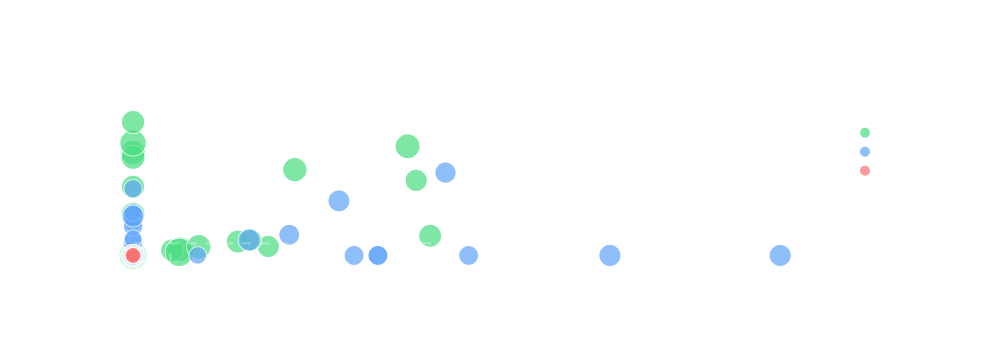

In [9]:
if "save_rate_pct" in df.columns and "share_rate_pct" in df.columns:
    fig = px.scatter(
        sr_df,
        x="save_rate_pct", y="share_rate_pct",
        color=tier_rel, size=ps_col,
        color_discrete_map={
            "Above Average": "#4ade80",
            "Average":       "#60a5fa",
            "Below Average": "#f87171"
        },
        title="Save Rate vs Share Rate — colored by Relative Performance Tier",
        labels={
            "save_rate_pct":  "Save Rate (%)",
            "share_rate_pct": "Share Rate (%)",
            tier_rel:         "Performance Tier"
        }
    )
    fig.add_vline(x=avg_save,  line_dash="dash",
                  line_color="rgba(255,255,255,0.3)",
                  annotation_text=f"Avg save {avg_save:.1f}%")
    fig.add_hline(y=avg_share, line_dash="dash",
                  line_color="rgba(255,255,255,0.3)",
                  annotation_text=f"Avg share {avg_share:.1f}%")
    fig.update_layout(
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)"
    )
    fig.show()


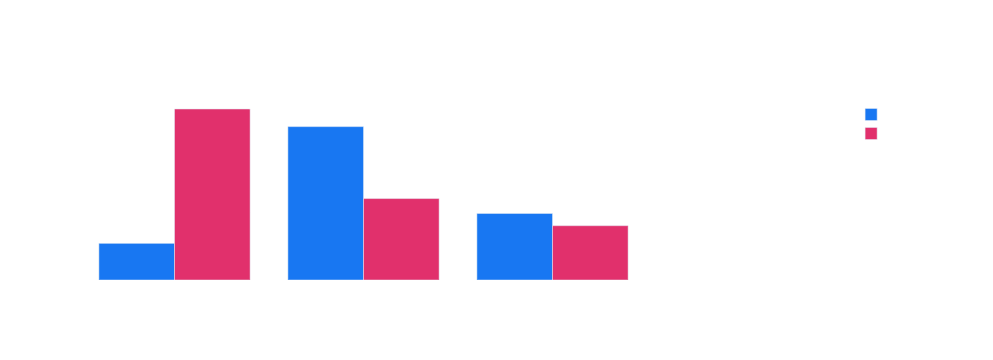

In [10]:
if "save_rate_pct" in df.columns and "share_rate_pct" in df.columns and type_col and type_col in df.columns:
    type_sr = df.groupby(type_col).agg(
        save_rate=("save_rate_pct", "mean"),
        share_rate=("share_rate_pct", "mean"),
        avg_score=(ps_col, "mean"),
        posts=(er_col, "count")
    ).round(2).reset_index()

    fig = go.Figure()
    fig.add_trace(go.Bar(
        name="Save Rate %", x=type_sr[type_col], y=type_sr["save_rate"],
        marker_color=BRAND_BLUE,
        text=type_sr["save_rate"].astype(str)+"%", textposition="outside"
    ))
    fig.add_trace(go.Bar(
        name="Share Rate %", x=type_sr[type_col], y=type_sr["share_rate"],
        marker_color=BRAND_PINK,
        text=type_sr["share_rate"].astype(str)+"%", textposition="outside"
    ))
    fig.update_layout(
        barmode="group",
        title="Save Rate vs Share Rate by Content Type",
        yaxis_title="Rate (%)",
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)"
    )
    fig.show()


## 4. Destination Analysis

Destinations detected from post descriptions.  
**Minimum 10 posts required** for reliable comparisons.  
Destinations with fewer posts are shown separately — do not draw conclusions from them.


In [11]:
if desc_col and desc_col in df.columns:

    destination_map = {
        "Europe": [
            "españa","spain","madrid","barcelona","sevilla","granada",
            "italia","italy","roma","venice","florence","venecia",
            "paris","france","london","england","scotland","escocia",
            "noruega","norway","fiordos","copenhague","copenhagen",
            "portugal","lisboa","grecia","greece","santorini",
            "amsterdam","alemania","germany","suiza","switzerland",
            "europa","europe","cáceres","córdoba","ronda"
        ],
        "Asia": [
            "asia","japan","japón","tokyo","bali","indonesia",
            "tailandia","thailand","bangkok","vietnam","hanoi",
            "singapur","singapore","china","india","nepal",
            "filipinas","philippines","cambodia","malasia","malaysia"
        ],
        "Americas": [
            "mexico","méxico","cancun","colombia","peru","perú",
            "machu picchu","brasil","brazil","rio de janeiro",
            "argentina","buenos aires","chile","patagonia","ushuaia",
            "cuba","costa rica","guatemala","panama","ecuador",
            "america del sur","south america","latin america"
        ],
        "Caribbean": [
            "caribe","caribbean","bahamas","jamaica","aruba",
            "republica dominicana","punta cana","puerto rico"
        ],
        "Middle East & Africa": [
            "dubai","abu dhabi","qatar","marruecos","morocco",
            "marrakech","egipto","egypt","africa","safari","kenia"
        ],
        "USA & Canada": [
            "new york","nueva york","miami","orlando","disney",
            "las vegas","los angeles","california","hawaii",
            "canada","toronto","vancouver"
        ]
    }

    def detect_destination(text):
        if pd.isna(text): return "Unknown"
        text_lower = str(text).lower()
        for region, keywords in destination_map.items():
            if any(kw in text_lower for kw in keywords):
                return region
        return "Unknown"

    df["destination"] = df[desc_col].apply(detect_destination)
    dest_counts = df["destination"].value_counts()

    print("Posts by destination:")
    for dest, count in dest_counts.items():
        flag = "✅" if count >= MIN_DEST_POSTS else "⚠️ "
        print(f"   {flag} {dest:30s}: {count:3d} posts {'(reliable)' if count >= MIN_DEST_POSTS else '(insufficient data)'}")
else:
    print("⚠️  No description column found.")


Posts by destination:
   ✅ Europe                        :  50 posts (reliable)
   ✅ Unknown                       :  28 posts (reliable)
   ✅ USA & Canada                  :  18 posts (reliable)
   ✅ Asia                          :  10 posts (reliable)
   ⚠️  Caribbean                     :   8 posts (insufficient data)
   ⚠️  Middle East & Africa          :   6 posts (insufficient data)
   ⚠️  Americas                      :   5 posts (insufficient data)


In [12]:
if desc_col and "destination" in df.columns:

    dest_all = (
        df[df["destination"] != "Unknown"]
          .groupby("destination")
          .agg(
              Posts=(er_col, "count"),
              Avg_Score=(ps_col, "mean"),
              Avg_ER=(er_col, "mean"),
              Median_Score=(ps_col, "median")
          )
          .round(2)
    )

    # Split reliable vs insufficient
    reliable     = dest_all[dest_all["Posts"] >= MIN_DEST_POSTS].sort_values("Avg_Score", ascending=False)
    insufficient = dest_all[dest_all["Posts"] <  MIN_DEST_POSTS].sort_values("Avg_Score", ascending=False)

    print(f"✅ RELIABLE DESTINATIONS (≥{MIN_DEST_POSTS} posts):")
    display(reliable)

    print(f"\n⚠️  INSUFFICIENT DATA (<{MIN_DEST_POSTS} posts) — do not draw conclusions:")
    display(insufficient)

    if len(reliable) > 0:
        best_dest_ps = reliable["Avg_Score"].idxmax()
        best_dest_er = reliable["Avg_ER"].idxmax()
        print(f"\n⭐ Best reliable destination by Score : {best_dest_ps} ({reliable.loc[best_dest_ps,'Avg_Score']:.2f}/100)")
        print(f"⭐ Best reliable destination by ER    : {best_dest_er} ({reliable.loc[best_dest_er,'Avg_ER']:.2f}%)")
        if best_dest_ps != best_dest_er:
            print(f"\n⚠️  Results differ — use Performance Score as primary metric.")
            print(f"   → Prioritize {best_dest_ps} content.")
    else:
        best_dest_ps = "N/A"
        print("⚠️  No destination has enough posts for reliable analysis yet.")
        print(f"   Post more content about specific destinations to unlock this analysis.")


✅ RELIABLE DESTINATIONS (≥10 posts):


,Posts,Avg_Score,Avg_ER,Median_Score
destination,,,,
Asia,10,33.61,13.47,31.92
Europe,50,31.55,16.04,30.80
USA & Canada,18,27.91,16.64,26.44



⚠️  INSUFFICIENT DATA (<10 posts) — do not draw conclusions:


,Posts,Avg_Score,Avg_ER,Median_Score
destination,,,,
Middle East & Africa,6,37.70,17.83,40.58
Americas,5,35.58,21.41,36.33
Caribbean,8,30.28,15.75,28.10



⭐ Best reliable destination by Score : Asia (33.61/100)
⭐ Best reliable destination by ER    : USA & Canada (16.64%)

⚠️  Results differ — use Performance Score as primary metric.
   → Prioritize Asia content.


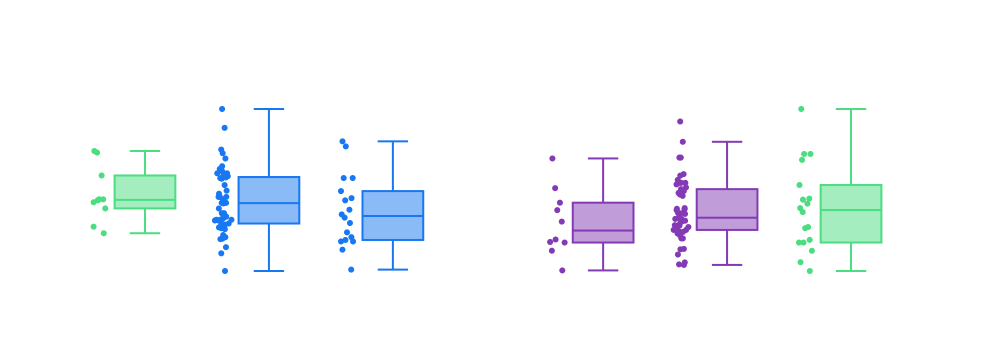

In [13]:
if desc_col and "destination" in df.columns and len(reliable) > 0:

    plot_df = df[df["destination"].isin(reliable.index)].copy()

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=["Performance Score by Destination",
                                        "Engagement Rate by Destination"])

    for dest in reliable.index:
        sub      = plot_df[plot_df["destination"] == dest]
        color_ps = "#4ade80" if dest == best_dest_ps else BRAND_BLUE
        color_er = "#4ade80" if dest == best_dest_er else BRAND_PURPLE

        fig.add_trace(go.Box(
            y=sub[ps_col], name=dest, showlegend=False,
            marker_color=color_ps, boxpoints="all", jitter=0.3
        ), row=1, col=1)

        fig.add_trace(go.Box(
            y=sub[er_col], name=dest, showlegend=False,
            marker_color=color_er, boxpoints="all", jitter=0.3
        ), row=1, col=2)

    fig.update_layout(
        title=f"Reliable Destinations (≥{MIN_DEST_POSTS} posts) — Score vs ER",
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)"
    )
    fig.show()


## 5. Caption Analysis — What Copy Works Best?

We analyze caption length and whether posts featuring a **specific tour**
(with dates, destination and implicit pricing) outperform generic inspirational posts.

> **Key finding from investigation:** The original `has_cta` variable showed
> a negative correlation with Performance Score. After examining actual posts,
> we found the real driver is not the CTA itself but whether the post
> promotes a **specific tour** vs generic content.


In [14]:
if desc_col and desc_col in df.columns:

    desc_df = df[[desc_col, er_col, ps_col, tier_rel]].dropna().copy()

    # Text metrics
    desc_df["char_count"]    = desc_df[desc_col].str.len()
    desc_df["word_count"]    = desc_df[desc_col].str.split().str.len()
    desc_df["emoji_count"]   = desc_df[desc_col].apply(
        lambda x: len([c for c in str(x) if ord(c) > 127462])
    )
    desc_df["hashtag_count"] = desc_df[desc_col].str.count(r"#\w+")

    # Specific tour detection
    desc_df["has_specific_tour"] = desc_df[desc_col].str.contains(
        r"\d{1,2}\s+de\s+\w+|desde\s+\$|días|noches|saliendo\s+desde",
        case=False, na=False, regex=True
    )

    print("Caption statistics:")
    print(f"   Avg characters      : {desc_df['char_count'].mean():.0f}")
    print(f"   Avg words           : {desc_df['word_count'].mean():.0f}")
    print(f"   Avg emojis          : {desc_df['emoji_count'].mean():.1f}")
    print(f"   Avg hashtags        : {desc_df['hashtag_count'].mean():.1f}")
    print(f"   Posts with specific tour: {desc_df['has_specific_tour'].sum()} ({desc_df['has_specific_tour'].mean()*100:.0f}%)")
else:
    print("⚠️  No description column found.")


Caption statistics:
   Avg characters      : 515
   Avg words           : 79
   Avg emojis          : 6.5
   Avg hashtags        : 5.2
   Posts with specific tour: 43 (36%)


In [15]:
if desc_col and "char_count" in desc_df.columns:

    # Caption length analysis
    desc_df["length_bucket"] = pd.cut(
        desc_df["char_count"],
        bins=[0, 150, 500, 1000, 9999],
        labels=["Short (<150)", "Medium (150-500)",
                "Long (500-1000)", "Very Long (>1000)"]
    )

    bucket_ps   = desc_df.groupby("length_bucket", observed=True)[ps_col].mean().round(2)
    bucket_er   = desc_df.groupby("length_bucket", observed=True)[er_col].mean().round(2)
    bucket_n    = desc_df.groupby("length_bucket", observed=True)[ps_col].count()
    best_len_ps = bucket_ps.idxmax()

    print("Performance by Caption Length:")
    for bucket in bucket_ps.index:
        n = bucket_n[bucket]
        flag = "✅" if n >= 10 else "⚠️ "
        print(f"   {flag} {str(bucket):20s}: Score={bucket_ps[bucket]:.2f} | ER={bucket_er[bucket]:.2f}% | n={n}")

    print(f"\n⭐ Best length by Score: {best_len_ps}")
    if bucket_n[best_len_ps] < 10:
        print(f"   ⚠️  Only {bucket_n[best_len_ps]} posts — not enough for reliable conclusion.")


Performance by Caption Length:
   ⚠️  Short (<150)        : Score=37.77 | ER=17.15% | n=3
   ✅ Medium (150-500)    : Score=29.65 | ER=14.73% | n=57
   ✅ Long (500-1000)     : Score=31.66 | ER=15.87% | n=58
   ⚠️  Very Long (>1000)   : Score=23.07 | ER=11.42% | n=3

⭐ Best length by Score: Short (<150)
   ⚠️  Only 3 posts — not enough for reliable conclusion.


In [16]:
if desc_col and "has_specific_tour" in desc_df.columns:

    tour_group    = desc_df[desc_df["has_specific_tour"]==True][ps_col].dropna()
    no_tour_group = desc_df[desc_df["has_specific_tour"]==False][ps_col].dropna()

    t_stat, p_val = stats.ttest_ind(tour_group, no_tour_group, equal_var=False)
    diff          = tour_group.mean() - no_tour_group.mean()

    print("SPECIFIC TOUR POSTS vs GENERIC CONTENT:")
    print()
    print(f"   Posts with specific tour : {len(tour_group):3d} | avg Score={tour_group.mean():.2f}")
    print(f"   Generic content posts    : {len(no_tour_group):3d} | avg Score={no_tour_group.mean():.2f}")
    print(f"   Difference               : {diff:+.2f} points")
    print()
    print(f"   Welch t-test: t={t_stat:.3f}, p={p_val:.4f}")
    print()

    if p_val < ALPHA:
        print(f"   ✅ SIGNIFICANT (p<{ALPHA}): Specific tour posts perform better.")
        print(f"   → Include dates, destinations and tour details in more posts.")
    elif p_val < 0.10:
        print(f"   📊 MARGINAL TREND (p={p_val:.3f}, not yet significant at α={ALPHA}):")
        print(f"   → Specific tour posts show +{diff:.1f} point tendency vs generic content.")
        print(f"   → More data needed to confirm — currently {len(tour_group)} tour posts.")
        print(f"   → Recommendation: increase specific tour posts to 60+ to retest.")
    else:
        print(f"   ❌ NOT SIGNIFICANT: No reliable difference detected yet.")
        print(f"   → Continue testing with more posts.")


SPECIFIC TOUR POSTS vs GENERIC CONTENT:

   Posts with specific tour :  43 | avg Score=33.41
   Generic content posts    :  78 | avg Score=29.13
   Difference               : +4.28 points

   Welch t-test: t=1.862, p=0.0665

   📊 MARGINAL TREND (p=0.067, not yet significant at α=0.05):
   → Specific tour posts show +4.3 point tendency vs generic content.
   → More data needed to confirm — currently 43 tour posts.
   → Recommendation: increase specific tour posts to 60+ to retest.


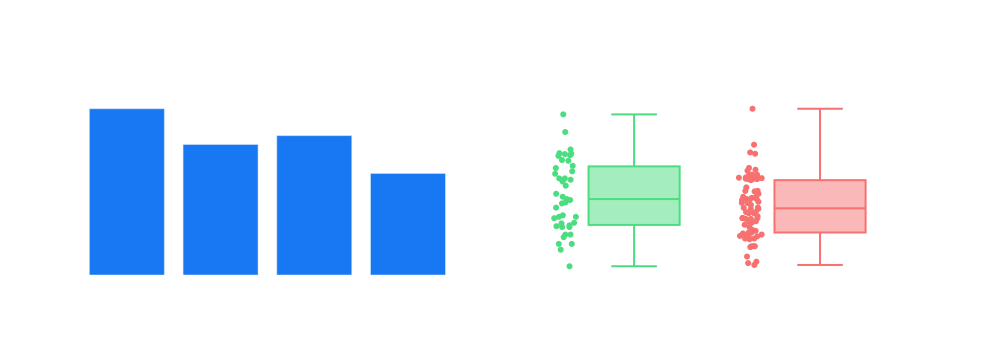

Correlations vs Performance Score:
   Emoji count    : +0.003  ❌ Minimal
   Hashtag count  : -0.030   ⚠️ Negative
   Caption length : -0.031  ⚠️ Negative


In [17]:
if desc_col and "has_specific_tour" in desc_df.columns:

    fig = make_subplots(rows=1, cols=2,
                        subplot_titles=["Caption Length vs Score",
                                        "Specific Tour vs Generic — Score"])

    # Caption length bars
    bucket_df = bucket_ps.reset_index()
    bucket_df.columns = ["Length", "Score"]
    fig.add_trace(go.Bar(
        x=bucket_df["Length"].astype(str),
        y=bucket_df["Score"],
        marker_color=BRAND_BLUE,
        text=bucket_df["Score"], textposition="outside"
    ), row=1, col=1)

    # Specific tour boxplot
    for label, group, color in [
        ("With Specific Tour", tour_group, "#4ade80"),
        ("Generic Content",    no_tour_group, "#f87171")
    ]:
        fig.add_trace(go.Box(
            y=group, name=label, showlegend=False,
            marker_color=color, boxpoints="all", jitter=0.3
        ), row=1, col=2)

    fig.update_layout(
        title="Caption Analysis — Length & Specific Tour Impact",
        showlegend=False,
        plot_bgcolor="rgba(0,0,0,0)",
        paper_bgcolor="rgba(0,0,0,0)",
        font_color="rgba(255,255,255,0.8)"
    )
    fig.show()

    # Correlations
    corr_emoji = desc_df["emoji_count"].corr(desc_df[ps_col])
    corr_hash  = desc_df["hashtag_count"].corr(desc_df[ps_col])
    corr_chars = desc_df["char_count"].corr(desc_df[ps_col])

    print("Correlations vs Performance Score:")
    print(f"   Emoji count    : {corr_emoji:+.3f}  {'✅ Positive' if corr_emoji > 0.1 else '❌ Minimal' if corr_emoji > 0 else '⚠️ Negative'}")
    print(f"   Hashtag count  : {corr_hash:+.3f}   {'✅ Positive' if corr_hash > 0.1 else '❌ Minimal' if corr_hash > 0 else '⚠️ Negative'}")
    print(f"   Caption length : {corr_chars:+.3f}  {'✅ Positive' if corr_chars > 0.1 else '❌ Minimal' if corr_chars > 0 else '⚠️ Negative'}")


## 6. Recommended Experiments

In [18]:
print("=" * 65)
print("  RECOMMENDED EXPERIMENTS — TRAVEL MEX TOURS")
print("=" * 65)

print("""
📅 EXPERIMENT 1 — Weekend Posting
   Status : ⚠️  Only 1 weekend post — test not yet valid
   Action : Post 2x per weekend (Saturday 10:00 + Sunday 11:00) for 3 months
   Target : ≥5 weekend posts to activate Weekend vs Weekday analysis
   Payoff : Know if weekend audience engages differently

⏰ EXPERIMENT 2 — Time Slot Variation
   Status : ⚠️  63% of posts at 9:00 — hard to compare other slots
   Action : Post 10x in Late Morning (10-12) and 10x in Afternoon (13-17)
   Target : ≥10 posts per slot for reliable ANOVA
   Payoff : Confirm if Early Morning is really the best slot

✈️  EXPERIMENT 3 — Destination Volume
   Status : ⚠️  Only Europe (50) and USA & Canada (18) have enough data
   Action : Create 10+ posts each for Asia, Caribbean, and Americas
   Target : ≥10 posts per destination for reliable comparison
   Payoff : Know which destinations drive the most engagement

📝 EXPERIMENT 4 — Specific Tour Content
   Status : 📊 Marginal trend (p=0.07) — needs more data to confirm
   Action : Increase specific tour posts (with dates + destination) to 60+
   Target : ≥60 specific tour posts for reliable t-test
   Payoff : Confirm if tour-specific content outperforms generic posts
""")
print("=" * 65)
print("  All analyses activate automatically when new data is uploaded.")
print("=" * 65)


  RECOMMENDED EXPERIMENTS — TRAVEL MEX TOURS

📅 EXPERIMENT 1 — Weekend Posting
   Status : ⚠️  Only 1 weekend post — test not yet valid
   Action : Post 2x per weekend (Saturday 10:00 + Sunday 11:00) for 3 months
   Target : ≥5 weekend posts to activate Weekend vs Weekday analysis
   Payoff : Know if weekend audience engages differently

⏰ EXPERIMENT 2 — Time Slot Variation
   Status : ⚠️  63% of posts at 9:00 — hard to compare other slots
   Action : Post 10x in Late Morning (10-12) and 10x in Afternoon (13-17)
   Target : ≥10 posts per slot for reliable ANOVA
   Payoff : Confirm if Early Morning is really the best slot

✈️  EXPERIMENT 3 — Destination Volume
   Status : ⚠️  Only Europe (50) and USA & Canada (18) have enough data
   Action : Create 10+ posts each for Asia, Caribbean, and Americas
   Target : ≥10 posts per destination for reliable comparison
   Payoff : Know which destinations drive the most engagement

📝 EXPERIMENT 4 — Specific Tour Content
   Status : 📊 Marginal trend

## 7. Executive Summary

In [19]:
print("=" * 65)
print("  CONTENT STRATEGY SUMMARY — TRAVEL MEX TOURS")
print("=" * 65)

# Clusters
print(f"\n🔍 POST CLUSTERS")
for cid, name in cluster_names.items():
    sub = cluster_df[cluster_df["cluster"] == cid]
    print(f"   {name:22s}: {len(sub):3d} posts | Score={sub[ps_col].mean():.1f} | ER={sub[er_col].mean():.1f}%")
print(f"   → Study {(cluster_df['cluster']==high_cluster).sum()} High Impact posts and replicate patterns")

# Save vs Share
if "save_rate_pct" in df.columns and "share_rate_pct" in df.columns:
    winner = "Save" if df["save_rate_pct"].mean() > df["share_rate_pct"].mean() else "Share"
    print(f"\n💾 SAVE vs SHARE")
    print(f"   Save={df['save_rate_pct'].mean():.2f}% | Share={df['share_rate_pct'].mean():.2f}%")
    print(f"   → Create {winner.lower()}-worthy content")
    print(f"   → CTA: {'Save this for your next trip ✈️' if winner=='Save' else 'Comparte con alguien que necesita unas vacaciones 🌴'}")

# Destination
if "destination" in df.columns and len(reliable) > 0:
    print(f"\n✈️  DESTINATIONS (reliable only)")
    print(f"   Best by Score : {best_dest_ps}")
    for dest in reliable.head(3).index:
        print(f"   {dest:25s}: Score={reliable.loc[dest,'Avg_Score']:.1f} | ER={reliable.loc[dest,'Avg_ER']:.1f}%")
elif "destination" in df.columns:
    print(f"\n✈️  DESTINATIONS")
    print(f"   ⚠️  No destination has ≥{MIN_DEST_POSTS} posts yet.")
    print(f"   → Run Experiment 3 to unlock this analysis")

# Caption
if desc_col and "has_specific_tour" in desc_df.columns:
    print(f"\n✍️  CAPTIONS")
    print(f"   Specific tour posts: Score={tour_group.mean():.2f} (n={len(tour_group)})")
    print(f"   Generic content    : Score={no_tour_group.mean():.2f} (n={len(no_tour_group)})")
    print(f"   → Marginal trend (+{diff:.1f} pts, p={p_val:.3f}) — needs more data to confirm")
    print(f"   → Provisional: include dates and tour details in more posts")

print(f"\n🎯 ACTION PLAN")
print(f"   1. Study your {(cluster_df['cluster']==high_cluster).sum()} High Impact posts and replicate their patterns")
if "destination" in df.columns and len(reliable) > 0:
    print(f"   2. Prioritize {best_dest_ps} destination content (most reliable data)")
print(f"   3. Run the 4 recommended experiments over the next 3 months")
print(f"   4. Upload new data monthly — all analyses update automatically")
print(f"   5. Re-run full notebook when you have 50+ new posts")
print("=" * 65)


  CONTENT STRATEGY SUMMARY — TRAVEL MEX TOURS

🔍 POST CLUSTERS
   🔥 High Impact         :  15 posts | Score=42.5 | ER=21.7%
   ✅ Solid Posts         :  21 posts | Score=40.9 | ER=13.2%
   📉 Low Impact          :  87 posts | Score=26.2 | ER=14.8%
   → Study 15 High Impact posts and replicate patterns

💾 SAVE vs SHARE
   Save=0.41% | Share=1.00%
   → Create share-worthy content
   → CTA: Comparte con alguien que necesita unas vacaciones 🌴

✈️  DESTINATIONS (reliable only)
   Best by Score : Asia
   Asia                     : Score=33.6 | ER=13.5%
   Europe                   : Score=31.6 | ER=16.0%
   USA & Canada             : Score=27.9 | ER=16.6%

✍️  CAPTIONS
   Specific tour posts: Score=33.41 (n=43)
   Generic content    : Score=29.13 (n=78)
   → Marginal trend (+4.3 pts, p=0.067) — needs more data to confirm
   → Provisional: include dates and tour details in more posts

🎯 ACTION PLAN
   1. Study your 15 High Impact posts and replicate their patterns
   2. Prioritize Asia destinati